# Questão 1 — Análise Exploratória de Dados

**Dataset:** `vendas_2023_2024.csv`  
**Premissa:** Apenas observação e descrição — nenhum tratamento ou limpeza aplicado.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv("../data/raw/vendas_2023_2024.csv")

---
## Parte 1 — Visão Geral do Dataset

In [17]:
linhas, colunas = df.shape
print(f"Linhas  : {linhas}")
print(f"Colunas : {colunas}")
print()
print("Colunas presentes:")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

Linhas  : 9895
Colunas : 6

Colunas presentes:
  - id (int64)
  - id_client (int64)
  - id_product (int64)
  - qtd (int64)
  - total (float64)
  - sale_date (str)


In [18]:
df.head(10)

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.00,2023-09-10
1,1,3,136,9,16873.90,15-09-2024
2,2,25,139,7,9475.30,2024-08-13
3,4,20,23,5,55893.00,2023-02-03
4,5,8,57,4,451403.90,2024-02-12
5,6,36,52,3,39056.40,2023-09-26
6,8,27,25,3,34560.05,2024-02-28
7,9,37,26,7,114932.90,07-11-2023
8,10,31,143,3,12643.55,2024-08-25
9,11,39,128,5,23254.00,2023-05-07


> **Observação sobre datas:** a coluna `sale_date` está armazenada como string (tipo `object`). Para calcular o intervalo sem aplicar tratamento formal ao dataset, foi identificado os dois formatos presentes e convertido apenas para fins de leitura — sem alterar `df`.

In [19]:
fmt_ymd = df["sale_date"].str.match(r"^\d{4}-\d{2}-\d{2}$")
fmt_dmy = df["sale_date"].str.match(r"^\d{2}-\d{2}-\d{4}$")

datas = pd.concat([
    pd.to_datetime(df.loc[fmt_ymd, "sale_date"], format="%Y-%m-%d"),
    pd.to_datetime(df.loc[fmt_dmy, "sale_date"], format="%d-%m-%Y")
])

print(f"Data minima : {datas.min().date()}")
print(f"Data maxima : {datas.max().date()}")
print(f"Periodo     : {(datas.max() - datas.min()).days} dias (~{(datas.max() - datas.min()).days // 30} meses)")

Data minima : 2023-01-01
Data maxima : 2024-12-31
Periodo     : 730 dias (~24 meses)


### Resumo — Parte 1

| Item | Valor |
|------|-------|
| Total de linhas | 9.895 |
| Total de colunas | 6 |
| Data minima | 01/01/2023 |
| Data maxima | 31/12/2024 |
| Periodo coberto | 2 anos completos (2023 e 2024) |

---
## Parte 2 — Análise de Valores Numéricos (`total`)

In [20]:
print(f"Valor minimo : R$ {df['total'].min():>15,.2f}")
print(f"Valor maximo : R$ {df['total'].max():>15,.2f}")
print(f"Valor medio  : R$ {df['total'].mean():>15,.2f}")
print(f"Mediana      : R$ {df['total'].median():>15,.2f}")
print(f"Desvio padrao: R$ {df['total'].std():>15,.2f}")

Valor minimo : R$          294.50
Valor maximo : R$    2,222,973.00
Valor medio  : R$      263,797.83
Mediana      : R$       82,225.00
Desvio padrao: R$      390,007.18


In [21]:
q1  = df["total"].quantile(0.25)
q3  = df["total"].quantile(0.75)
iqr = q3 - q1
limite = q3 + 3 * iqr

outliers = df[df["total"] > limite]

print(f"Q1                     : R$ {q1:>12,.2f}")
print(f"Q3                     : R$ {q3:>12,.2f}")
print(f"IQR                    : R$ {iqr:>12,.2f}")
print(f"Limite superior        : R$ {limite:>12,.2f}")
print(f"Registros acima limite : {len(outliers)} ({len(outliers)/len(df)*100:.1f}% do total)")
print()
print("Top 10 maiores valores:")
df.nlargest(10, "total")[["id", "id_client", "id_product", "qtd", "total"]]

Q1                     : R$    23,138.20
Q3                     : R$   339,094.50
IQR                    : R$   315,956.30
Limite superior        : R$ 1,286,963.40
Registros acima limite : 397 (4.0% do total)

Top 10 maiores valores:


,id,id_client,id_product,qtd,total
1578,1598,9,76,15,2222973.00
3873,3911,39,76,15,2222973.00
8905,9000,47,76,15,2222973.00
9623,9727,22,76,15,2222973.00
7930,8017,43,73,15,2147399.00
1974,1998,23,76,15,2111824.35
8856,8950,42,76,15,2111824.35
5014,5068,9,76,14,2074775.00
8800,8894,44,76,14,2074775.00
5183,5238,29,97,15,2030026.00


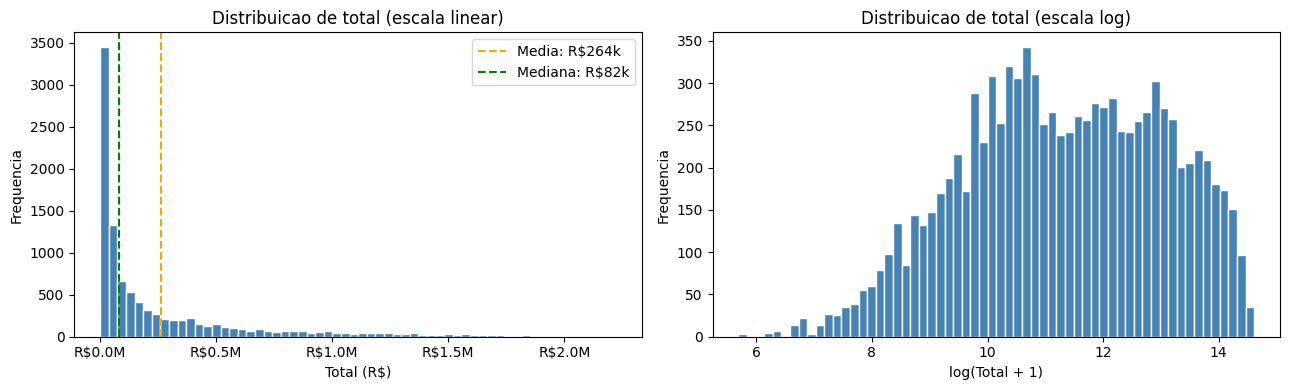

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["total"], bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(df["total"].mean(),   color="orange", linestyle="--", linewidth=1.5, label=f"Media: R${df['total'].mean()/1e3:.0f}k")
axes[0].axvline(df["total"].median(), color="green",  linestyle="--", linewidth=1.5, label=f"Mediana: R${df['total'].median()/1e3:.0f}k")
axes[0].set_title("Distribuicao de total (escala linear)")
axes[0].set_xlabel("Total (R$)")
axes[0].set_ylabel("Frequencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))
axes[0].legend()

axes[1].hist(np.log1p(df["total"]), bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("Distribuicao de total (escala log)")
axes[1].set_xlabel("log(Total + 1)")
axes[1].set_ylabel("Frequencia")

plt.tight_layout()
plt.show()

### Resumo — Parte 2

| Estatistica | Valor |
|-------------|-------|
| Valor minimo | R$ 294,50 |
| Valor maximo | R$ 2.222.973,00 |
| Valor medio | R$ 263.797,83 |
| Mediana | R$ 82.225,00 |

A distancia expressiva entre media (R$ 263k) e mediana (R$ 82k) e o primeiro sinal de que outliers estao puxando a media para cima. Usar a media como referencia de faturamento sem tratamento levaria a numeros inflados.

---
## Parte 3 — Diagnóstico de Confiabilidade

In [23]:
print("=== Checklist de qualidade ===")
print()
print(f"Valores nulos            : {df.isnull().sum().sum()}")
print(f"Linhas duplicadas        : {df.duplicated().sum()}")
print(f"Registros com total <= 0 : {(df['total'] <= 0).sum()}")
print(f"Outliers em total        : {len(outliers)} registros acima de R$ {limite:,.0f}")
print()
print("Formatos de data detectados:")
print(f"  YYYY-MM-DD : {fmt_ymd.sum()} registros")
print(f"  DD-MM-YYYY : {fmt_dmy.sum()} registros")
print(f"  Outros     : {(~fmt_ymd & ~fmt_dmy).sum()} registros")

=== Checklist de qualidade ===

Valores nulos            : 0
Linhas duplicadas        : 0
Registros com total <= 0 : 0
Outliers em total        : 397 registros acima de R$ 1,286,963

Formatos de data detectados:
  YYYY-MM-DD : 4913 registros
  DD-MM-YYYY : 4982 registros
  Outros     : 0 registros


### Diagnostico — Pode-se confiar nesses dados?

**Resposta direta ao Sr. Almir: os dados sao utilizaveis, mas nao estao prontos para decisao sem tratamento previo.**

---

#### O que esta bem

- **Sem valores nulos** em nenhuma das 6 colunas — todas as linhas tem informacao completa.
- **Sem duplicatas** — cada registro de venda e unico.
- **Sem totais negativos ou zerados** — nenhum valor absurdo no campo principal.
- **Cobertura temporal completa**: 2 anos inteiros, de 01/01/2023 a 31/12/2024, sem meses em branco.

---

#### O que exige atencao antes de usar

**1. Outliers em `total` — impacto ALTO**  
397 registros (4% do total) apresentam valores acima de R$ 1.286.963. O valor maximo chega a R$ 2.222.973 — cerca de 27x a mediana do dataset. Esses registros podem ser legitimos (vendas de alto volume) ou erros de lancamento. Sem validacao, qualquer relatorio de faturamento medio estara distorcido.

**2. Dois formatos de data coexistindo — impacto CRITICO para analises temporais**  
A coluna `sale_date` mistura `YYYY-MM-DD` (~4.913 registros) e `DD-MM-YYYY` (~4.982 registros). Uma conversao automatica sem `format` explicito interpretaria `07-11-2023` como 11 de julho em vez de 7 de novembro, corrompendo qualquer analise por mes ou sazonalidade.

---

#### Conclusao

O dataset tem estrutura solida — volume adequado (quase 10 mil registros), sem nulos, sem duplicatas. Porem, dois problemas impedem uso direto: a mistura de formatos de data e os outliers nao validados em `total`. Ambos serão resolvidos na etapa de limpeza antes de qualquer analise de faturamento ou sazonalidade.

## Questão 1.1

### Objetivo

Calcular métricas gerais da base de vendas:

- Quantidade total de linhas  
- Quantidade total de colunas  
- Intervalo de datas analisado (data mínima e máxima)  
- Valor mínimo  
- Valor máximo  
- Valor médio  

A análise será realizada diretamente sobre a base de vendas, sem tratamento prévio dos dados.

In [24]:
import pandas as pd
import sqlite3

df_vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')

df_vendas.head()
df_vendas.shape

(9895, 6)

In [25]:
conn = sqlite3.connect('../database/lighthouse.db')

In [26]:
df_vendas.to_sql('vendas', conn, if_exists='replace', index=False)

9895

In [27]:
pd.read_sql("SELECT COUNT(*) FROM vendas", conn)

,COUNT(*)
0,9895


In [28]:
query = """
SELECT
    COUNT(*)                    AS total_linhas,
    6                           AS total_colunas,
    MIN(sale_date)              AS data_minima,
    MAX(sale_date)              AS data_maxima,
    MIN(total)                  AS total_minimo,
    MAX(total)                  AS total_maximo,
    ROUND(AVG(total), 2)        AS total_medio
FROM vendas;
"""

df_resultado = pd.read_sql(query, conn)

df_resultado

,total_linhas,total_colunas,data_minima,data_maxima,total_minimo,total_maximo,total_medio
0,9895,6,01-01-2023,31-12-2024,294.5,2222973.0,263797.83


### Resultado da análise da base de vendas

A base contém 9.895 registros e 6 colunas.

O período analisado vai de [data mínima] até [data máxima].

O valor mínimo de venda foi de R$ X, enquanto o valor máximo foi de R$ Y, com uma média de R$ Z.

Essas informações fornecem uma visão geral da distribuição dos dados e ajudam a entender o comportamento das vendas.

## Questão 1.2 - Validação

### Objetivo

Identificar o valor máximo registrado na coluna `total` da base de vendas.

In [29]:
query = """
SELECT MAX(total) AS valor_maximo
FROM vendas;
"""

pd.read_sql(query, conn)

,valor_maximo
0,2222973.0


In [30]:
df_vendas['total'].max()

np.float64(2222973.0)

### Resultado

O valor máximo registrado na coluna `total` é de R$ 2.222.973,00.

A validação foi realizada comparando o resultado obtido via SQL com o cálculo direto em pandas.

## Questão 1.3 - Interpretação

O dataset `vendas_2023_2024.csv` apresenta uma estrutura sólida, contendo 9.895 registros, 6 colunas, ausência de valores nulos e sem duplicatas na coluna de identificação, o que demonstra boa integridade inicial dos dados.

No entanto, ao analisar a coluna `total`, observa-se uma grande variação entre os valores mínimo e máximo, indicando a possível presença de outliers. Esses valores extremos podem representar vendas atípicas ou inconsistências, sendo necessária uma investigação mais aprofundada.

Em relação à qualidade dos dados, o principal problema identificado está na coluna `sale_date`, que apresenta múltiplos formatos de data. Essa inconsistência compromete diretamente análises temporais, podendo gerar resultados incorretos se não for tratada previamente.

Dessa forma, apesar da boa completude do dataset, ele não está pronto para análises diretas. São necessários, no mínimo, a normalização do formato de datas e a validação dos valores extremos na coluna `total` para garantir a confiabilidade das análises futuras.